## 1. Design the Threat Index

We chose to do a application-specific impact, relating to good conditions for a beach day. Our target audience would be the general public, specifically beach goers. This can include tourists and people who live near a beach. 

We chose the variables temperature, dewpoint, precipitation, cloud cover, and wind. We chose temperature and dewpoint to represent the comfort level of the temperature outside for beach goers. With precipitation and cloud cover, it represents whether the weather is nice enough outside for people to sit at the beach. Wind speed was chosen because it can have an impact on  objects used at the beach, such as umbrellas, surfing, parasailing, and other beach activities. The variable that has the most weight is precipitation at 40%. This is because precipitation would be the number one factor when deciding whether or not to go to the beach that day. The variable with the second most weight is temperature because temperatures below a certain threshold would be too cold to sit at the beach, and temperatures above a certain threshold would have extreme heat risks. For the index, we based it around a 1-10 scale, with 10 being the best conditions for a beach day. When creating the formula for the index, we incorporated the weights for each variable. For the temperature contribution in the index, we created our first range from 60 to 75, increasing linearly from 0 to 10. This is because as the temperature rises from 60 to 75, we are approaching peak conditions for our index. From 75 to 85, the line is constant at 10, because this is the peak condition for our index. Once it exceeds 85, the formula decreases exponentially toward 100. This is because, as the temperature rises above 85, beach conditions worsen as the risk of extreme heat increases. At any value greater than 100, the formula holds steady at 2.5 because once temperatures are beyond 100 degrees, the heat risk is too high for good beach conditions. It is not totally zero because some may still choose to go to the beach in these conditions. For dewpoint contribution, the starting range was values less than 45, which were rated a 2.5. The function then exponentially increased from 45 to 55, representing the gradual climb to pleasant conditions. From 55 to 75, the line is constant at a value of 10, because these are the best conditions for our index. Starting at 75, it begins to decay exponentially down to 85, as dewpoint conditions become unpleasant. From 85 to any value larger, the index drops to 0, as these are bad conditions for the beach. The total cloud cover contribution began its range at 10 for values between 0 and 35. The 

In [1]:
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
ds = xr.open_dataset('beachday_new.nc')
ds_time=ds.isel(valid_time=5)

sh: 1: getfattr: not found


In [4]:
temp_f = (ds_time['t2m'].values - 273.15)*(9/5) + 32
temp_f.max()
temp_contribution = np.zeros_like(temp_f)

In [5]:
mask = temp_f <=60
temp_contribution[mask] = 0

temp_contribution = np.zeros_like(temp_f) 
mask = (temp_f >= 60) & (temp_f < 75)
temp_contribution[mask] = (2/3)*(temp_f[mask] - 60)

mask = (temp_f >= 75) & (temp_f <= 85)
temp_contribution[mask] = 10.0

mask = (temp_f > 85) & (temp_f < 100)
temp_contribution[mask] = 10*(0.25)**((temp_f[mask]-85)/15) 

mask = temp_f >= 100
temp_contribution[mask] = 2.5

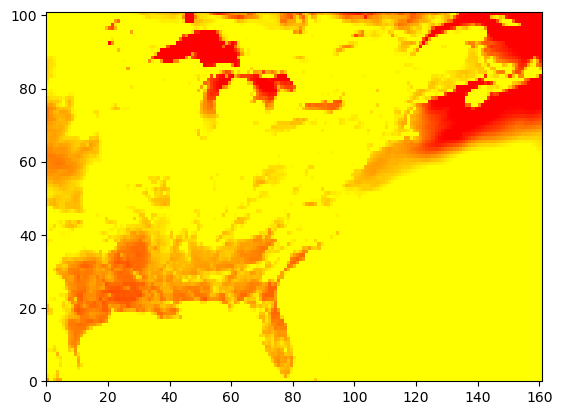

In [6]:
plt.pcolormesh(np.flipud(temp_contribution), cmap='autumn')

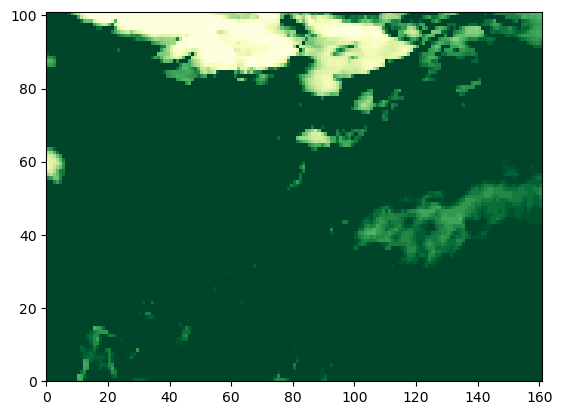

In [6]:
dewpoint_f = (ds_time['d2m'].values - 273.15)*(9/5) + 32
dewpoint_f.max() 

dewpoint_contribution = np.zeros_like(dewpoint_f)

mask = (dewpoint_f<45)
dewpoint_contribution[mask]=2.5

mask = (dewpoint_f >= 45) & (dewpoint_f < 55)
dewpoint_contribution[mask] = 0.004488*(1.1487)**(dewpoint_f[mask])

mask = (dewpoint_f >= 55) & (dewpoint_f <= 75)
dewpoint_contribution[mask] = 10.0

mask = (dewpoint_f > 75) & (dewpoint_f < 85)
dewpoint_contribution[mask] = 11*np.exp(-0.2398*(dewpoint_f[mask]-75))-1

mask = dewpoint_f >= 85
dewpoint_contribution[mask] = 0

plt.pcolormesh(np.flipud(dewpoint_contribution), cmap='YlGn')

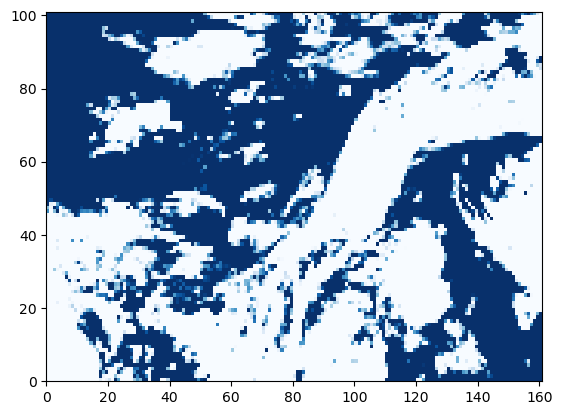

In [7]:
totalcloud = (ds_time['tcc'].values)
totalcloud.max() 

cloud_contribution = np.zeros_like(totalcloud)


mask = (totalcloud >= 0) & (totalcloud <= 35)
cloud_contribution[mask] = 10

mask = (totalcloud > 35) & (totalcloud < 80)
cloud_contribution[mask] = ((-2/9)*(totalcloud[mask]))+(160/9)


mask = (totalcloud >= 80) & (totalcloud <= 100)
cloud_contribution[mask] = 0

plt.pcolormesh(np.flipud(cloud_contribution), cmap='Blues')

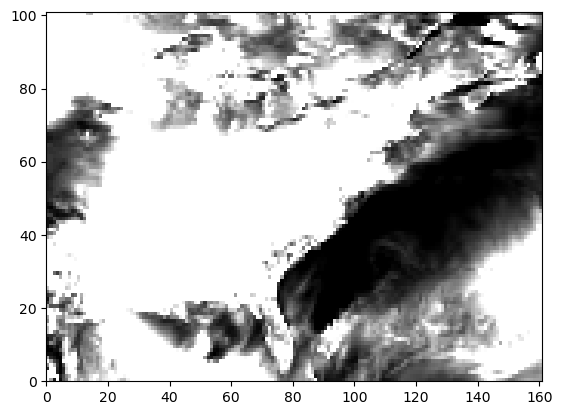

In [8]:
u=(ds_time['u10'].values)
v=(ds_time['v10'].values)

wind= np.sqrt(u**2+v**2)
wind_mph= wind*2.23693629 

wind_mph.max()

wind_contribution = np.zeros_like(wind_mph)


mask = (wind_mph >= 0) & (wind_mph < 10)
wind_contribution[mask] = 10

mask = (wind_mph > 10) & (wind_mph < 20)
wind_contribution[mask] =121*np.exp(-0.24*(wind_mph[mask]))-1


mask = (wind_mph >= 20) 
wind_contribution[mask] = 0

plt.pcolormesh(np.flipud(wind_contribution), cmap='gray')

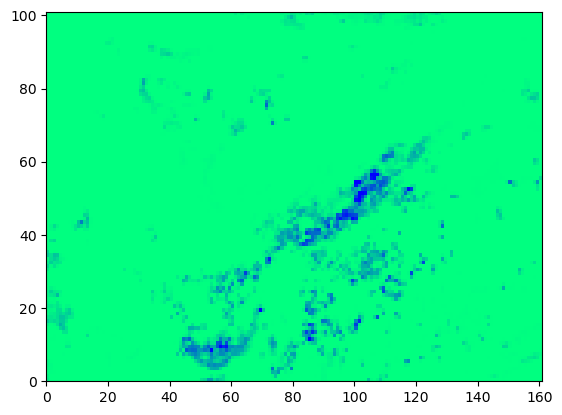

In [20]:
prate_mm = ds_time['prate'].values
prate_mm_hr = prate_mm*3600
prate_in_hr= prate_mm_hr*0.0393701

prate_in_hr.max() 

precip_contribution = np.zeros_like(prate_in_hr)

mask = (prate_in_hr >= 0) & (prate_in_hr <= 0.2)
precip_contribution[mask] = (-50*(prate_in_hr[mask]))+10

plt.pcolormesh(np.flipud(precip_contribution), cmap='winter')

In [10]:
BD_index = (temp_contribution*0.3+dewpoint_contribution*.005+cloud_contribution*.10+wind_contribution*.15+precip_contribution*.40)*100
BD_index

array([[955.     , 955.     , 955.     , ..., 492.57635, 445.9458 ,
        423.8236 ],
       [955.     , 955.     , 955.     , ..., 510.1867 , 495.04205,
        478.058  ],
       [955.     , 955.     , 955.     , ..., 548.2714 , 508.3835 ,
        487.36395],
       ...,
       [854.9889 , 854.9776 , 854.9889 , ..., 882.10754, 881.6742 ,
        887.36194],
       [818.827  , 854.99036, 838.33344, ..., 889.1239 , 892.0413 ,
        897.54126],
       [725.14966, 799.4462 , 651.4219 , ..., 899.47375, 899.7471 ,
        899.78314]], shape=(101, 161), dtype=float32)

In [26]:
def beachday_index(ds,ts):
    ds_time=ds.isel(valid_time=ts)

    temp_f = (ds_time['t2m'].values - 273.15)*(9/5) + 32
    temp_contribution = np.zeros_like(temp_f)
    mask = (temp_f >= 60) & (temp_f < 75)
    temp_contribution[mask] = (2/3)*(temp_f[mask] - 60)
    mask = (temp_f >= 75) & (temp_f <= 85)
    temp_contribution[mask] = 10.0
    mask = (temp_f > 85) & (temp_f < 100)
    temp_contribution[mask] = 10*(0.25)**((temp_f[mask]-85)/15) 
    mask = temp_f >= 100
    temp_contribution[mask] = 2.5

    dewpoint_f = (ds_time['d2m'].values - 273.15)*(9/5) + 32
    dewpoint_f.max() 
    dewpoint_contribution = np.zeros_like(dewpoint_f)
    mask = (dewpoint_f<45)
    dewpoint_contribution[mask]=2.5
    mask = (dewpoint_f >= 45) & (dewpoint_f < 55)
    dewpoint_contribution[mask] = 0.004488*(1.1487)**(dewpoint_f[mask])
    mask = (dewpoint_f >= 55) & (dewpoint_f <= 75)
    dewpoint_contribution[mask] = 10.0
    mask = (dewpoint_f > 75) & (dewpoint_f < 85)
    dewpoint_contribution[mask] = 11*np.exp(-0.2398*(dewpoint_f[mask]-75))-1
    mask = dewpoint_f >= 85
    dewpoint_contribution[mask] = 0

    totalcloud = (ds_time['tcc'].values)
    totalcloud.max() 
    cloud_contribution = np.zeros_like(totalcloud)
    mask = (totalcloud >= 0) & (totalcloud <= 35)
    cloud_contribution[mask] = 10
    mask = (totalcloud > 35) & (totalcloud < 80)
    cloud_contribution[mask] = ((-2/9)*(totalcloud[mask]))+(160/9)
    mask = (totalcloud >= 80) & (totalcloud <= 100)
    cloud_contribution[mask] = 0

    u=(ds_time['u10'].values)
    v=(ds_time['v10'].values)
    wind= np.sqrt(u**2+v**2)
    wind_mph= wind*2.23693629 
    wind_mph.max()
    wind_contribution = np.zeros_like(wind_mph)
    mask = (wind_mph >= 0) & (wind_mph < 10)
    wind_contribution[mask] = 10
    mask = (wind_mph > 10) & (wind_mph < 20)
    wind_contribution[mask] =121*np.exp(-0.24*(wind_mph[mask]))-1
    mask = (wind_mph >= 20) 
    wind_contribution[mask] = 0

    prate_mm = ds_time['prate'].values
    prate_mm_hr = prate_mm*3600
    prate_in_hr= prate_mm_hr*0.0393701
    precip_contribution = np.zeros_like(prate_in_hr)
    mask = (prate_in_hr >= 0) & (prate_in_hr <= 0.2)
    precip_contribution[mask] = (-50*(prate_in_hr[mask]))+10

    BD_index = (temp_contribution*0.3+dewpoint_contribution*.005+cloud_contribution*.10+wind_contribution*.15+precip_contribution*.40)
    return BD_index, temp_contribution, dewpoint_contribution, cloud_contribution, wind_contribution, precip_contribution

In [27]:
timestep=5
bd,temp,dewpoint,cloud,wind,precip=beachday_index(ds,timestep)
validtime= ds.valid_time.values[timestep]

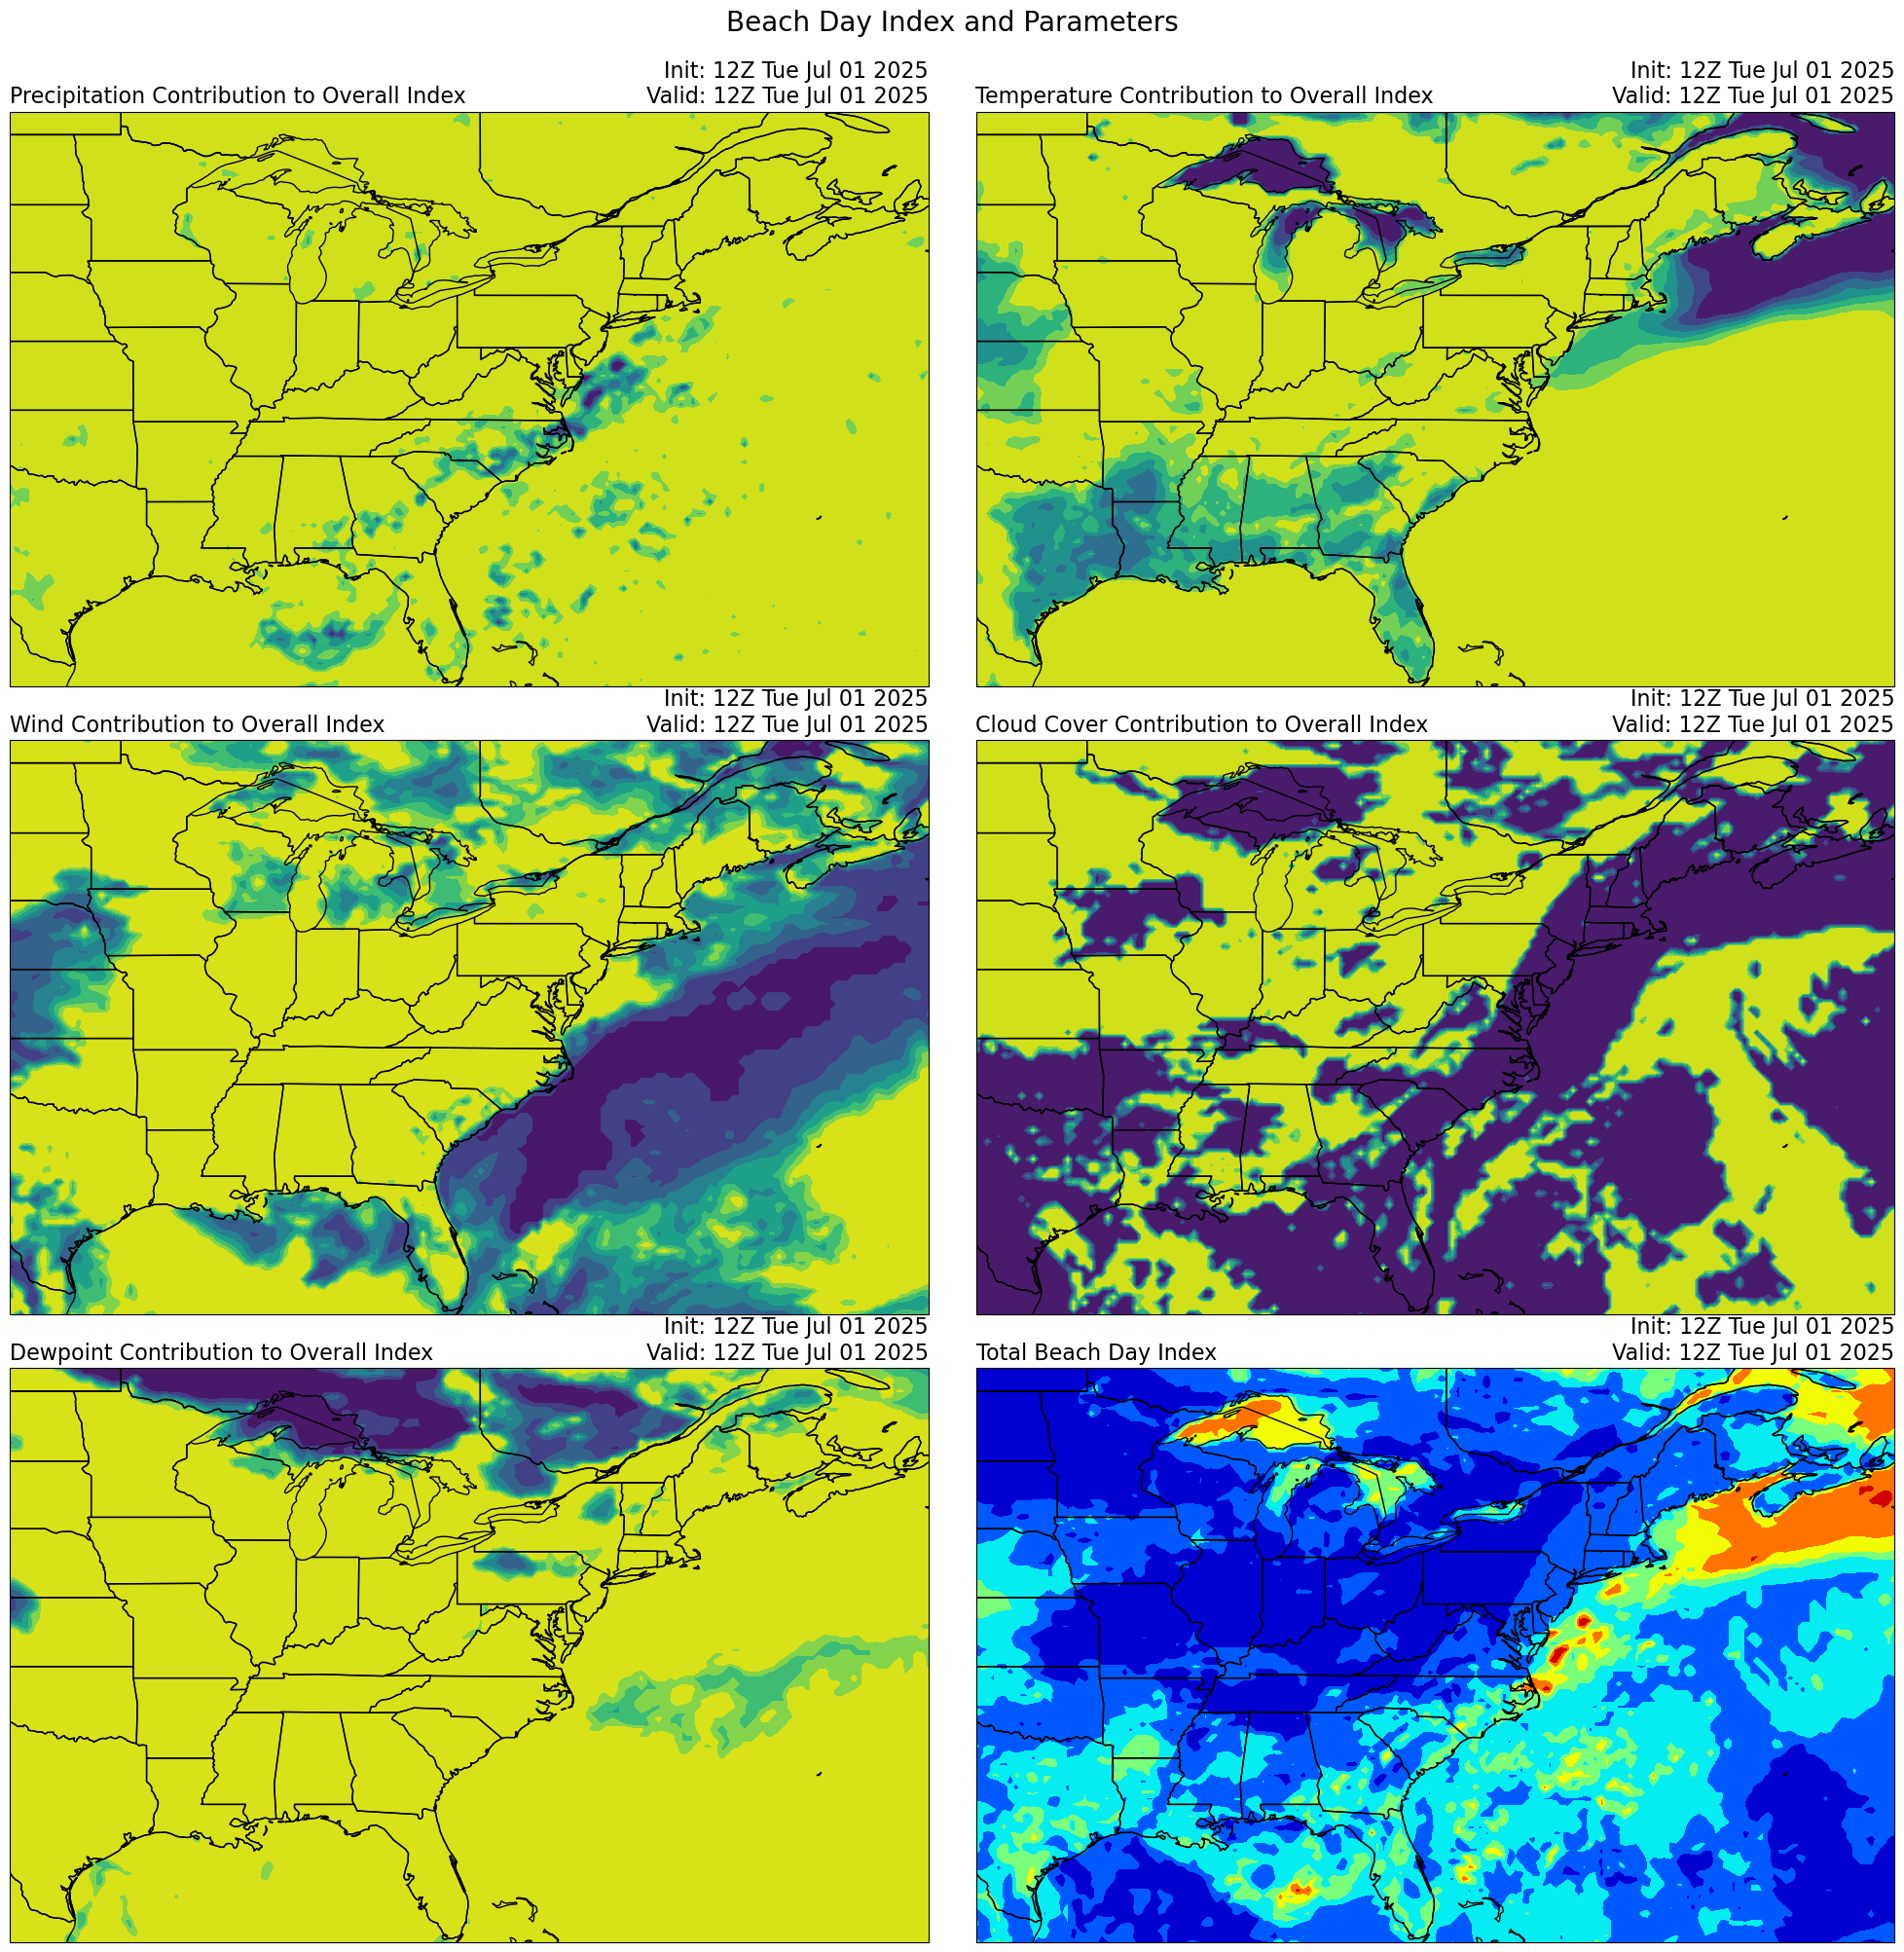

In [28]:
#2-by-3 panel plot
fig = plt.figure(figsize=(20, 20))
ax_1 = fig.add_subplot(3, 2, 1, projection=ccrs.PlateCarree())
ax_2 = fig.add_subplot(3, 2, 2, projection=ccrs.PlateCarree())
ax_3 = fig.add_subplot(3, 2, 3, projection=ccrs.PlateCarree())
ax_4 = fig.add_subplot(3, 2, 4, projection=ccrs.PlateCarree())
ax_5 = fig.add_subplot(3, 2, 5, projection=ccrs.PlateCarree())
ax_6 = fig.add_subplot(3, 2, 6, projection=ccrs.PlateCarree())
fig.suptitle("Beach Day Index and Parameters", fontsize=20, y=1.0)

#Subplot 1: Precipitation
init_time = pd.to_datetime(ds.time.values).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds_time.time.values).strftime('%HZ %a %b %d %Y')
ax_1.set_title("Precipitation Contribution to Overall Index", loc='left', fontsize=16)
ax_1.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=16)
ax_1.add_feature(cfeature.COASTLINE)
ax_1.add_feature(cfeature.BORDERS)
ax_1.add_feature(cfeature.STATES)
ax_1.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
ax_1.contourf(ds['longitude'].values, ds['latitude'].values, precip, transform=ccrs.PlateCarree())

#Subplot 2: Temperature
init_time = pd.to_datetime(ds.time.values).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds_time.time.values).strftime('%HZ %a %b %d %Y')
ax_2.set_title("Temperature Contribution to Overall Index", loc='left', fontsize=16)
ax_2.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=16)
ax_2.add_feature(cfeature.COASTLINE)
ax_2.add_feature(cfeature.BORDERS)
ax_2.add_feature(cfeature.STATES)
ax_2.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
ax_2.contourf(ds['longitude'].values, ds['latitude'].values, temp, transform=ccrs.PlateCarree())

#Subplot 3: Wind
init_time = pd.to_datetime(ds.time.values).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds_time.time.values).strftime('%HZ %a %b %d %Y')
ax_3.set_title("Wind Contribution to Overall Index", loc='left', fontsize=16)
ax_3.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=16)
ax_3.add_feature(cfeature.COASTLINE)
ax_3.add_feature(cfeature.BORDERS)
ax_3.add_feature(cfeature.STATES)
ax_3.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
ax_3.contourf(ds['longitude'].values, ds['latitude'].values, wind, transform=ccrs.PlateCarree())

#Subplot 4: Cloud Cover
init_time = pd.to_datetime(ds.time.values).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds_time.time.values).strftime('%HZ %a %b %d %Y')
ax_4.set_title("Cloud Cover Contribution to Overall Index", loc='left', fontsize=16)
ax_4.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=16)
ax_4.add_feature(cfeature.COASTLINE)
ax_4.add_feature(cfeature.BORDERS)
ax_4.add_feature(cfeature.STATES)
ax_4.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
ax_4.contourf(ds['longitude'].values, ds['latitude'].values, cloud, transform=ccrs.PlateCarree())

#Subplot 5: Dewpoint
init_time = pd.to_datetime(ds.time.values).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds_time.time.values).strftime('%HZ %a %b %d %Y')
ax_5.set_title("Dewpoint Contribution to Overall Index", loc='left', fontsize=16)
ax_5.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=16)
ax_5.add_feature(cfeature.COASTLINE)
ax_5.add_feature(cfeature.BORDERS)
ax_5.add_feature(cfeature.STATES)
ax_5.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
ax_5.contourf(ds['longitude'].values, ds['latitude'].values, dewpoint , transform=ccrs.PlateCarree())

#Subplot 6: Overall Index
init_time = pd.to_datetime(ds.time.values).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds_time.time.values).strftime('%HZ %a %b %d %Y')
ax_6.set_title("Total Beach Day Index", loc='left', fontsize=16)
ax_6.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=16)
ax_6.add_feature(cfeature.COASTLINE)
ax_6.add_feature(cfeature.BORDERS)
ax_6.add_feature(cfeature.STATES)
ax_6.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
ax_6.contourf(ds['longitude'].values, ds['latitude'].values, bd , transform=ccrs.PlateCarree(), cmap='jet_r')

#Fix layout issues
plt.tight_layout()

In [41]:
run= pd.Timestamp("2025-05-14-12")

In [42]:
H = Herbie(run, model="gfs", fxx=12, save_dir='./data/', overwrite=True, source='ncei_analysis') 

✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2025-May-14 12:00 UTC F12 ┊ GRIB2 @ aws ┊ IDX @ aws


In [43]:
table= H.inventory() 

In [44]:
table.variable.unique()

array(['PRMSL', 'CLMR', 'ICMR', 'RWMR', 'SNMR', 'GRLE', 'REFD', 'REFC',
       'VIS', 'UGRD', 'VGRD', 'VRATE', 'GUST', 'HGT', 'TMP', 'RH', 'SPFH',
       'VVEL', 'DZDT', 'ABSV', 'O3MR', 'TCDC', 'HINDEX', 'MSLET', 'PRES',
       'TSOIL', 'SOILW', 'SOILL', 'CNWAT', 'WEASD', 'SNOD', 'PEVPR',
       'ICETK', 'DPT', 'APTMP', 'TMAX', 'TMIN', 'ICEG', 'CPOFP', 'CPRAT',
       'PRATE', 'APCP', 'ACPCP', 'WATR', 'CSNOW', 'CICEP', 'CFRZR',
       'CRAIN', 'LHTFL', 'SHTFL', 'GFLUX', 'UFLX', 'VFLX', 'SFCR',
       'FRICV', 'U-GWD', 'V-GWD', 'VEG', 'SOTYP', 'WILT', 'FLDCP',
       'SUNSD', 'LFTX', 'CAPE', 'CIN', 'PWAT', 'CWAT', 'TOZNE', 'LCDC',
       'MCDC', 'HCDC', 'CWORK', 'DSWRF', 'DLWRF', 'USWRF', 'ULWRF',
       'HLCY', 'USTM', 'VSTM', 'ICAHT', 'VWSH', '4LFTX', 'HPBL', 'POT',
       'PLPL', 'LAND', 'ICEC', 'ALBDO', 'ICETMP'], dtype=object)

In [45]:
H.inventory("PRATE")

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this
592,593,426022258,426608593.0,426022258-426608593,2025-05-14 12:00:00,2025-05-15,PRATE,surface,12 hour fcst,:PRATE:surface:12 hour fcst
594,595,427450791,428143607.0,427450791-428143607,2025-05-14 12:00:00,2025-05-15,PRATE,surface,6-12 hour ave fcst,:PRATE:surface:6-12 hour ave fcst


In [46]:
ss = r":((DPT|TMP):(2 m above ground))|(TCDC:entire atmosphere:\d+\s)" 
ss2 = r"((UGRD|VGRD):(10 m above ground))"
ss3 = r"(PRATE:surface:\d+ hour)"

H.inventory(ss3) 

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)


,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this
592,593,426022258,426608593.0,426022258-426608593,2025-05-14 12:00:00,2025-05-15,PRATE,surface,12 hour fcst,:PRATE:surface:12 hour fcst


In [47]:
H = FastHerbie([run], model="gfs", fxx=np.arange(6,246,6).tolist(), save_dir='./data/', overwrite=True)

In [48]:
fp = H.download(ss)
fp

fp2= H.download(ss2)
fp2

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

[PosixPath('data/gfs/20250514/subset_a01288d0__gfs.t12z.pgrb2.0p25.f012'),
 PosixPath('data/gfs/20250514/subset_a04388d0__gfs.t12z.pgrb2.0p25.f060'),
 PosixPath('data/gfs/20250514/subset_a0f188d0__gfs.t12z.pgrb2.0p25.f072'),
 PosixPath('data/gfs/20250514/subset_a0fb88d0__gfs.t12z.pgrb2.0p25.f108'),
 PosixPath('data/gfs/20250514/subset_a03288d0__gfs.t12z.pgrb2.0p25.f066'),
 PosixPath('data/gfs/20250514/subset_a0b288d0__gfs.t12z.pgrb2.0p25.f006'),
 PosixPath('data/gfs/20250514/subset_a02688d0__gfs.t12z.pgrb2.0p25.f090'),
 PosixPath('data/gfs/20250514/subset_a05e88d0__gfs.t12z.pgrb2.0p25.f078'),
 PosixPath('data/gfs/20250514/subset_a00788d0__gfs.t12z.pgrb2.0p25.f096'),
 PosixPath('data/gfs/20250514/subset_a01888d0__gfs.t12z.pgrb2.0p25.f120'),
 PosixPath('data/gfs/20250514/subset_a0ca88d0__gfs.t12z.pgrb2.0p25.f114'),
 PosixPath('data/gfs/20250514/subset_a00588d0__gfs.t12z.pgrb2.0p25.f084'),
 PosixPath('data/gfs/20250514/subset_a07888d0__gfs.t12z.pgrb2.0p25.f054'),
 PosixPath('data/gfs/2025

In [49]:
fp3= H.download(ss3)
fp3

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

[PosixPath('data/gfs/20250514/subset_a0f15fef__gfs.t12z.pgrb2.0p25.f072'),
 PosixPath('data/gfs/20250514/subset_a0185fef__gfs.t12z.pgrb2.0p25.f120'),
 PosixPath('data/gfs/20250514/subset_a00e5fef__gfs.t12z.pgrb2.0p25.f036'),
 PosixPath('data/gfs/20250514/subset_a00e5fef__gfs.t12z.pgrb2.0p25.f024'),
 PosixPath('data/gfs/20250514/subset_a05e5fef__gfs.t12z.pgrb2.0p25.f078'),
 PosixPath('data/gfs/20250514/subset_a0ca5fef__gfs.t12z.pgrb2.0p25.f114'),
 PosixPath('data/gfs/20250514/subset_a0605fef__gfs.t12z.pgrb2.0p25.f030'),
 PosixPath('data/gfs/20250514/subset_a0895fef__gfs.t12z.pgrb2.0p25.f018'),
 PosixPath('data/gfs/20250514/subset_a0055fef__gfs.t12z.pgrb2.0p25.f084'),
 PosixPath('data/gfs/20250514/subset_a0e75fef__gfs.t12z.pgrb2.0p25.f042'),
 PosixPath('data/gfs/20250514/subset_a01c5fef__gfs.t12z.pgrb2.0p25.f048'),
 PosixPath('data/gfs/20250514/subset_a0265fef__gfs.t12z.pgrb2.0p25.f090'),
 PosixPath('data/gfs/20250514/subset_a0fb5fef__gfs.t12z.pgrb2.0p25.f108'),
 PosixPath('data/gfs/2025

In [50]:
ds = xr.open_mfdataset(fp, combine='nested', concat_dim='valid_time', engine='cfgrib', coords='minimal', compat='override')
ds

ds2 = xr.open_mfdataset(fp2, combine='nested', concat_dim='valid_time', engine='cfgrib')
ds2

ds3 = xr.open_mfdataset(fp3, combine='nested', concat_dim='valid_time', engine='cfgrib')
ds3

ds4= xr.merge([ds,ds2,ds3], compat='override')
ds4

ds5 = ds4.sel(latitude=slice(50,25), longitude=slice(260,300))
ds5

/tmp/ipykernel_546653/2664281037.py:4: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds2 = xr.open_mfdataset(fp2, combine='nested', concat_dim='valid_time', engine='cfgrib')
/tmp/ipykernel_546653/2664281037.py:7: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds3 = xr.open_mfdataset(fp3, combine='nested', concat_d

<xarray.Dataset> Size: 16MB
Dimensions:            (latitude: 101, longitude: 161, valid_time: 40)
Coordinates:
  * latitude           (latitude) float64 808B 50.0 49.75 49.5 ... 25.25 25.0
  * longitude          (longitude) float64 1kB 260.0 260.2 260.5 ... 299.8 300.0
  * valid_time         (valid_time) datetime64[ns] 320B 2025-05-14T18:00:00 ....
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    heightAboveGround  float64 8B ...
    atmosphere         float64 8B ...
    surface            float64 8B 0.0
Data variables:
    t2m                (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 101, 161), meta=np.ndarray>
    d2m                (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 101, 161), meta=np.ndarray>
    tcc                (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 101, 161), meta=np.ndarray>
    u10                (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 101, 161), meta=np.ndarray>
    v10                (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 101, 161), meta=np.ndarray>
    prate              (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 101, 161), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-16T16:28 GRIB to CDM+CF via cfgrib-0.9.1...

In [51]:
fname = f'good_day.nc'
ds5.to_netcdf(fname)

In [52]:
ds = xr.open_dataset('good_day.nc')


sh: 1: getfattr: not found
